In [3]:
import json
import os

import pandas as pd
import seaborn as sns

# Plot the accuracy 

dir = '../data/results/experiments/clustering_experiment_4'

errors_df = pd.read_csv(os.path.join(dir, 'errors.csv')).drop(columns=['Unnamed: 0'])
complexity_df = pd.read_csv(os.path.join(dir, 'complexity.csv')).drop(columns=['Unnamed: 0'])

with open(os.path.join(dir, 'config.json')) as f:
    config = json.load(f)

print(config)

errors_df

{'wknn_k': 2, 'rf_param': 'sinr', 'cluster_rf_param': ['dummy', 'sinr', 'rsrq', 'rsrp', 'rssi'], 'operator_choice': [10], 'cluster_range': [0, 1], 'n_runs': 2, 'campaigns': [1, 2, 3, 4, 5, 6, 7, 8, 9], 'runtime': 148.88879013061523}


,0,1,param
0,3.839281,3.839281,dummy
1,4.199001,4.199001,dummy
2,3.839281,3.839281,sinr
3,4.199001,4.199001,sinr
4,3.880923,3.880923,rsrq
5,4.187632,4.187632,rsrq
6,4.306783,4.306783,rsrp
7,4.824615,4.824615,rsrp
8,5.154610,5.154610,rssi
9,5.497092,5.497092,rssi


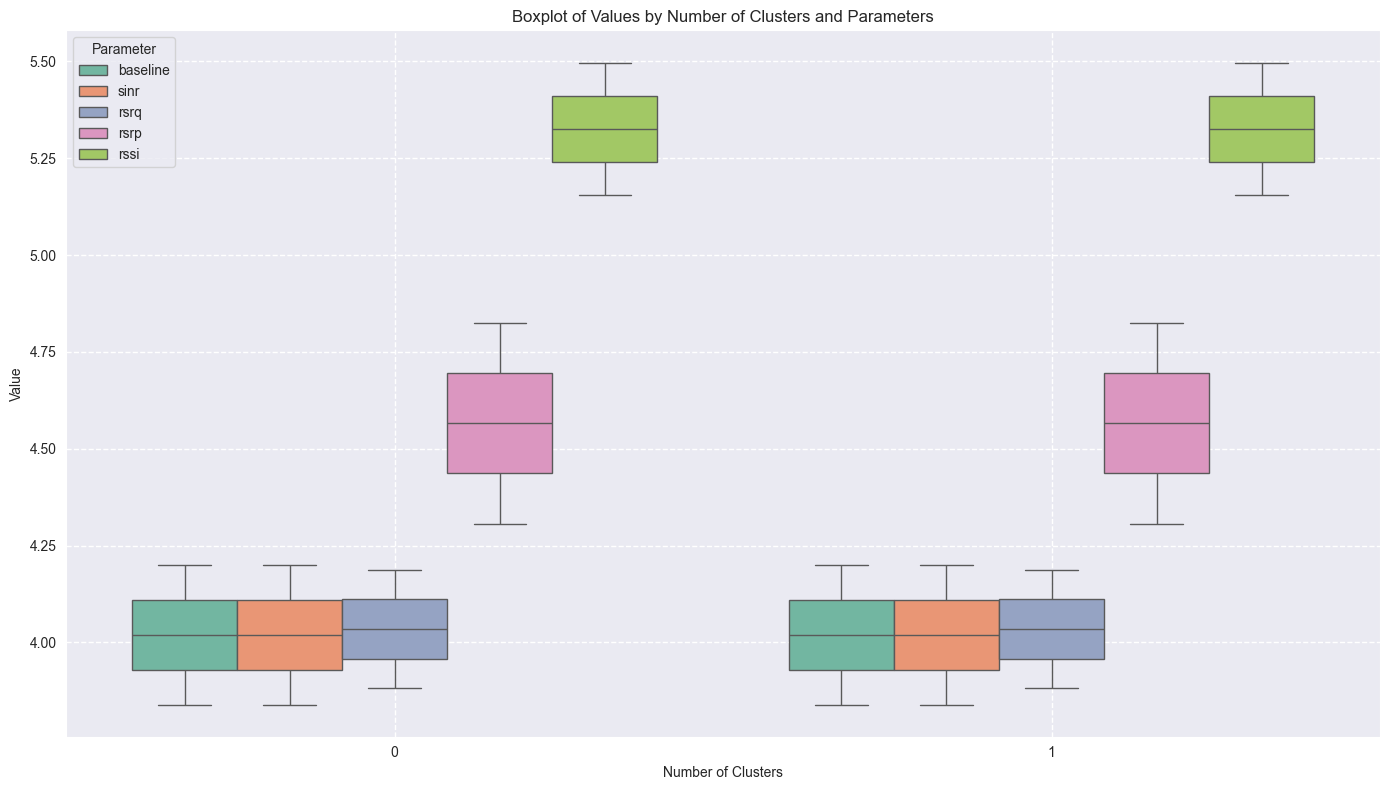

In [9]:
import matplotlib.pyplot as plt

errors_df['param'] = errors_df['param'].replace('dummy', 'baseline')

cluster_columns = [col for col in errors_df.columns if col not in ['param'] and not col.startswith('Unnamed')]

cluster_columns

melted_df = pd.melt(errors_df, id_vars=['param'], value_vars=cluster_columns,
                    var_name='clusters', value_name='value')

melted_df['clusters'] = melted_df['clusters'].astype(int)

plt.figure(figsize=(14, 8))

# Create the boxplot using seaborn
sns.boxplot(x='clusters', y='value', hue='param', data=melted_df, palette='Set2')

# Add labels and title
plt.xlabel('Number of Clusters')
plt.ylabel('Value')
plt.title('Boxplot of Values by Number of Clusters and Parameters')

# Improve the legend
plt.legend(title='Parameter')
plt.grid(color='white', linestyle='--', linewidth=1)

# Show the plot
plt.tight_layout()
plt.show()


In [ ]:

from scripts.plotting import make_boxplot
from scripts.utils import operators_to_str

param_str = f'RF Params: {config["rf_param"]}'
operator_str = f'Operators: {operators_to_str(config["operator_choice"])}'

title_string = f'wKNN {param_str} * {operator_str} * {config["n_runs"]} runs,'

if '0' in errors_df.columns:
    baseline_error = errors_df['0'].mean()
    baseline_complexity = complexity_df['0'].mean()
    baseline_runtime = runtime_df['0'].mean()

    errors_df = errors_df.drop(columns=['0'])
    complexity_df = complexity_df.drop(columns=['0'])
    runtime_df = runtime_df.drop(columns=['0'])

make_boxplot(
    df=errors_df,
    title=f'Positioning error: {title_string}',
    x_label='Number of clusters for KMeans',
    y_label='Error (m)',
    color='mediumseagreen',
    baseline=baseline_error,
)

make_boxplot(
    df=complexity_df,
    title=f'Complexity: {title_string}',
    x_label='Number of clusters for KMeans',
    y_label='Complexity metric',
    color='plum',
    baseline=baseline_complexity,
)

make_boxplot(
    df=runtime_df,
    title=f'Complexity: {title_string}',
    x_label='Number of clusters for KMeans',
    y_label='Runtime (s)',
    color='lightskyblue',
    baseline=baseline_runtime,
)

